In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob
import os

# Sklearn imports
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# # TensorFlow / Keras imports (Ref: Lab 5)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling1D,Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1.Data Pre-processing and exploration: 

## 1.a The class balance of the whole dataset.

### 1.a.1 Merge all CSV files from the datasets into a single large dataframe.

In [88]:
# Get file paths
base_dir = "MLT-CW-Dataset"
train_paths = glob.glob(os.path.join(base_dir, "*.csv"))
test_paths = glob.glob(os.path.join(base_dir, "test-set", "*.csv"))
file_paths = train_paths + test_paths

# Filter: Exclude the cleaned file S007_cleaned.csv
filtered_paths = [path for path in file_paths if "S007_cleaned.csv" not in path]

# Batch read and merge initial data
df_list = [pd.read_csv(path) for path in filtered_paths]

# Check if files were successfully read (in case of empty list due to path error)
if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print(f"Number of merged files: {len(filtered_paths)}")
    print(f"Final DataFrame shape: {df.shape}")
else:
    print("No CSV files found. Please check the file path or extension.")
df

Number of merged files: 22
Final DataFrame shape: (6691321, 10)


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,index,Unnamed: 0
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,NaN,NaN
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,NaN,NaN
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,NaN,NaN
3,2019-01-12 00:00:00.030,-0.648772,0.016579,-0.054284,-1.554248,-0.950978,-0.221140,6,NaN,NaN
4,2019-01-12 00:00:00.040,-0.355071,-0.051831,-0.113419,-0.547471,0.140903,-0.653782,6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6691316,2019-01-12 00:57:18.900,-0.967773,-0.048584,-0.283936,-1.006104,-0.023438,-0.016357,6,NaN,NaN
6691317,2019-01-12 00:57:18.920,-0.984131,-0.032227,-0.264648,-1.000488,-0.071289,-0.010742,6,NaN,NaN
6691318,2019-01-12 00:57:18.940,-0.969727,-0.031006,-0.295410,-0.990967,-0.083496,0.015137,6,NaN,NaN
6691319,2019-01-12 00:57:18.960,-0.968506,-0.030029,-0.281494,-0.980469,-0.077881,0.054199,6,NaN,NaN


### 1.a.2 Generate Class Balance Report

In [89]:
label_map = {
    1: 'Walking',
    2: 'Running',
    3: 'Shuffling',
    4: 'Stairs (ascending)',
    5: 'Stairs (descending)',
    6: 'Standing',
    7: 'Sitting',
    8: 'Lying',
    13: 'Cycling (sit)',
    14: 'Cycling (stand)',
    130: 'Cycling (sit, inactive)',
    140: 'Cycling (stand, inactive)'
}

# Create a new column 'activity_name' for readability
df['activity_name'] = df['label'].map(label_map)

# Count frequencies and calculate percentages
class_counts = df['activity_name'].value_counts()
class_percentages = df['activity_name'].value_counts(normalize=True) * 100

# Merge the results into a single DataFrame for review
balance_report = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

print("\n================= Class Balance Report ==================")
print(balance_report)


================= Class Balance Report ==================
                             Count  Percentage (%)
activity_name                                     
Sitting                    3152326       47.190290
Walking                    1100584       16.475732
Standing                    793985       11.885948
Lying                       437092        6.543263
Cycling (sit)               408560        6.116139
Running                     273582        4.095520
Shuffling                   261830        3.919593
Stairs (ascending)           77201        1.155698
Stairs (descending)          67867        1.015968
Cycling (stand)              58944        0.882391
Cycling (sit, inactive)      40195        0.601719
Cycling (stand, inactive)     7865        0.117739


### 1.a.3 Visualisation of Class Balance Report Results

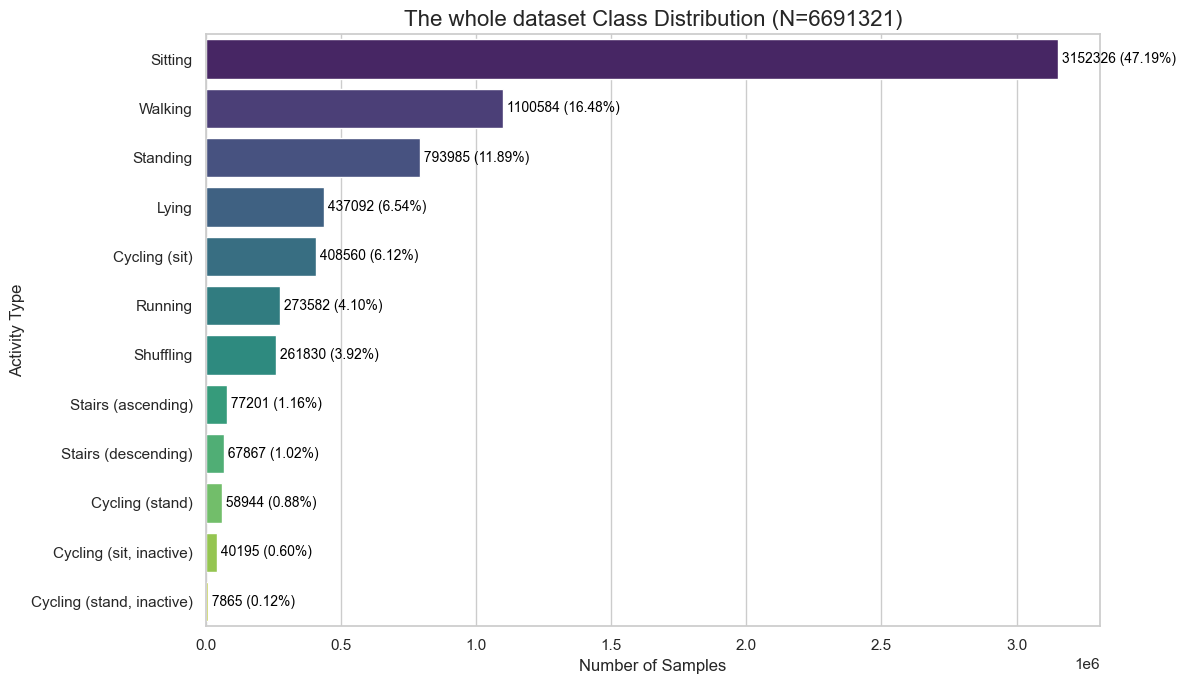

In [90]:
# Visualization
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Draw the bar plot
ax = sns.barplot(
    x=class_counts.values,
    y=class_counts.index,
    hue=class_counts.index,
    palette="viridis",
    legend=False
)

plt.title(f'The whole dataset Class Distribution (N={len(df)})', fontsize=16)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Activity Type', fontsize=12)

# Add "Count (Percentage)" next to the bars
for i, v in enumerate(class_counts.values):
    pct = class_percentages.values[i]
    ax.text(v, i, f' {v} ({pct:.2f}%)', color='black', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 1.b Drop the "Cycling" label data

In [91]:
def drop_cycling_data(df):
    """
    Drops all cycling-related labels (13, 14, 130, 140) from the dataset.
    """
    # 1. Define the list of cycling labels
    cycling_labels = [13, 14, 130, 140]

    # 2. Record original data size
    original_size = len(df)

    # 3. Perform filtering (drop rows where 'label' is in cycling_labels)
    df_deleted = df[~df['label'].isin(cycling_labels)].copy()

    # 4. Record new data size
    df_deleted_size = len(df_deleted)
    dropped_count = original_size - df_deleted_size

    # 5. Report results
    print(f"Original dataset size: {original_size} rows")
    print(f"Rows dropped: {dropped_count}")
    print(f"New dataset size: {df_deleted_size} rows")

    return df_deleted

In [92]:
if 'df' in locals() and not df.empty:
    print("--- Applying Drop Cycling Function ---")
    df_deleted = drop_cycling_data(df)

    # Verify if there is still cycling data remaining
    remaining_cycling = df_deleted[df_deleted['label'].isin([13, 14, 130, 140])]
    if remaining_cycling.empty:
        print("Verification successful: No cycling data remains in the dataset.")
    else:
        print("Warning: Cycling data still exists in the dataset!")
else:
    print("Please load data into the 'df' variable first.")

--- Applying Drop Cycling Function ---
Original dataset size: 6691321 rows
Rows dropped: 515564
New dataset size: 6175757 rows
Verification successful: No cycling data remains in the dataset.


## 1.c Merge the "stairs" labels data

In [93]:
def merge_stairs_data(df):
    """
    Merges different stairs labels (e.g., ascending, descending) in the dataset
    into one unified label. Also reports the data scale and sample distribution
    changes before and after the merge.
    """

    stairs_labels = [4, 5]
    new_label = 9

    # 1. Create a copy to avoid SettingWithCopyWarning
    df_merged = df.copy()

    # 2. Record status before merging
    original_size = len(df)
    # Calculate the count of original stairs data
    original_stairs_count = df[df['label'].isin(stairs_labels)].shape[0]

    print(f"--- Before Merging ---")
    print(f"Original dataset size: {original_size} rows")
    print(f"Count of old stairs labels {stairs_labels}: {original_stairs_count}")

    # 3. Execute the merge
    df_merged.loc[df_merged['label'].isin(stairs_labels), 'label'] = new_label

    # 4. Record status after merging
    new_size = len(df_merged)
    # Calculate the count of the new stairs label
    new_stairs_count = df_merged[df_merged['label'] == new_label].shape[0]

    print(f"\n--- After Merging ---")
    print(f"New dataset size: {new_size} rows (Should remain unchanged)")
    print(f"Count of new stairs label [{new_label}]: {new_stairs_count}")

    # 5. Verify integrity
    if original_stairs_count == new_stairs_count:
        print(f"\nResult: Successfully merged {original_stairs_count} samples.")
    else:
        print(f"\nWarning: Sample counts do not match! (Original: {original_stairs_count}, New: {new_stairs_count})")

    return df_merged

In [94]:
if 'df' in locals() and not df.empty:
    print("--- Applying Merge Stairs Function ---")
    
    # Call function
    df_merged = merge_stairs_data(df)
    
    # Final verification: Check whether any old labels remain.
    old_labels_to_check = [4, 5] 
    remaining_old = df[df['label'].isin(old_labels_to_check)]
    


--- Applying Merge Stairs Function ---
--- Before Merging ---
Original dataset size: 6691321 rows
Count of old stairs labels [4, 5]: 145068

--- After Merging ---
New dataset size: 6691321 rows (Should remain unchanged)
Count of new stairs label [9]: 145068

Result: Successfully merged 145068 samples.


## 1.d Use appropriate sampling and visualisations to report and interpret the "Walking" label data.

In [95]:
def visualize_walking_pattern(df, window_size=300, start_index=1000):
    """
    Visualizes the sensor data pattern for the 'Walking' category.
    Uses slicing to obtain a clear waveform.
    """
    # 1. Filter Walking data (Label = 1)
    walking_data = df[df['label'] == 1].copy()

    if walking_data.empty:
        print("Error: No data found for Walking (label=1).")
        return

    # 2. Appropriate Sampling
    # Reset index to ensure continuity
    walking_data = walking_data.reset_index(drop=True)

    # Check if the data is long enough
    if len(walking_data) < start_index + window_size:
        print("Warning: Insufficient Walking data. Plotting all available data.")
        sample = walking_data
    else:
        # Slicing: Take a stable segment from the middle, avoiding noise at the start/end
        sample = walking_data.iloc[start_index : start_index + window_size]

    # 3. Set Plotting Style
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Get x-axis data and convert to numpy array to avoid FutureWarning
    x_data = sample.index.to_numpy()

    # --- Subplot 1: Back Sensor ---
    axes[0].plot(x_data, sample['back_x'].to_numpy(), label='Back X (Down)', color='r', linewidth=1.5)
    axes[0].plot(x_data, sample['back_y'].to_numpy(), label='Back Y (Left)', color='g', linewidth=1.5)
    axes[0].plot(x_data, sample['back_z'].to_numpy(), label='Back Z (Forward)', color='b', linewidth=1.5)
    axes[0].set_title('Walking Pattern - Back Sensor', fontsize=14)
    axes[0].set_ylabel('Acceleration (g)', fontsize=12)
    axes[0].legend(loc='upper right')

    # --- Subplot 2: Thigh Sensor ---
    axes[1].plot(x_data, sample['thigh_x'].to_numpy(), label='Thigh X (Down)', color='r', linewidth=1.5, linestyle='--')
    axes[1].plot(x_data, sample['thigh_y'].to_numpy(), label='Thigh Y (Right)', color='g', linewidth=1.5, linestyle='--')
    axes[1].plot(x_data, sample['thigh_z'].to_numpy(), label='Thigh Z (Backward)', color='b', linewidth=1.5, linestyle='--')
    axes[1].set_title('Walking Pattern - Thigh Sensor', fontsize=14)
    axes[1].set_xlabel('Sample Index (Time)', fontsize=12)
    axes[1].set_ylabel('Acceleration (g)', fontsize=12)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

Generate a visualisation chart of walking patterns...


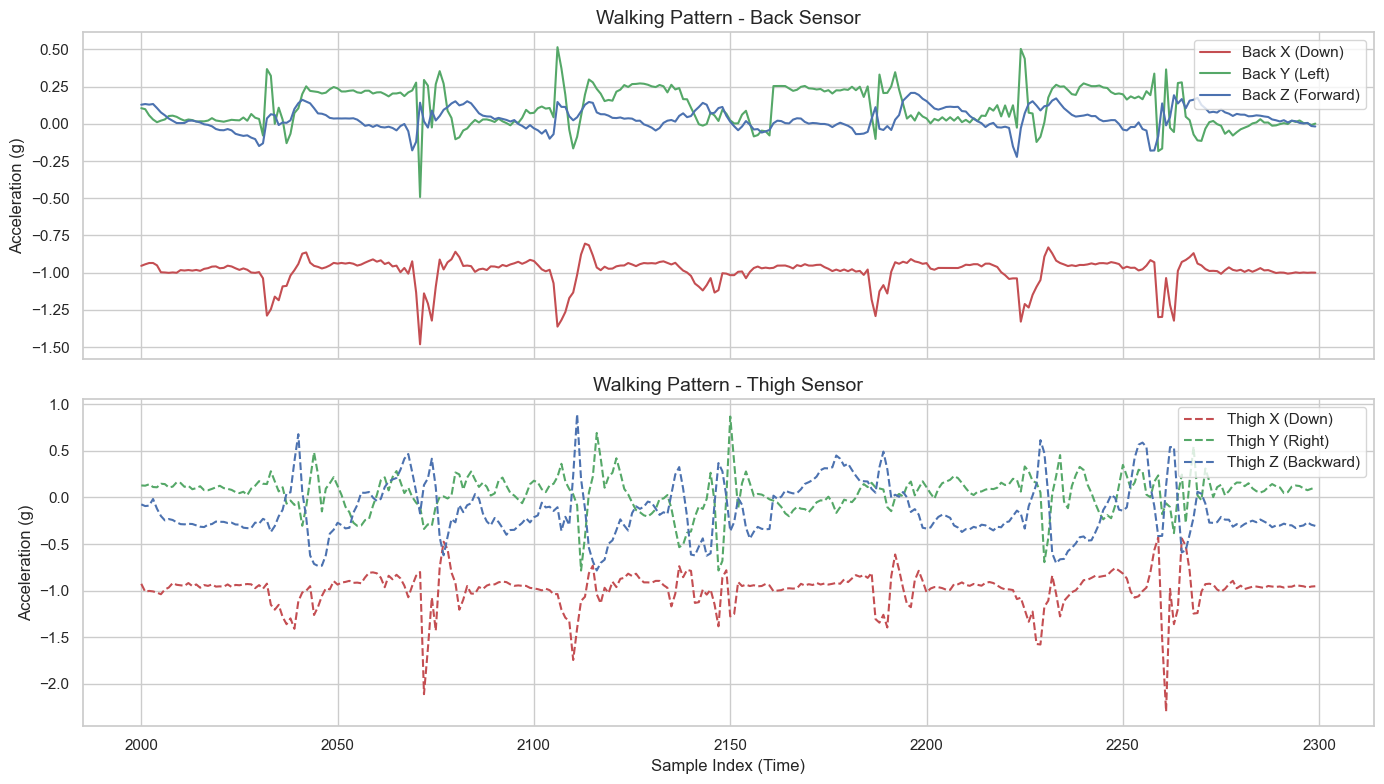

In [96]:
if 'df' in locals() and not df.empty:
    print("Generate a visualisation chart of walking patterns...")
    # Try sampling 300 points (approx. 6 seconds)
    visualize_walking_pattern(df_merged, window_size=300, start_index=2000)
else:
    print("Please run the previous preprocessing steps to generate df_merged.")

# 2.Data Cleaning and Preparation

## 2.a S007 Data Quality Analysis

--- S007 Data Quality Analysis Report ---

1. Label Distribution:
label
1      24889
3      12693
4       1370
5       1550
6      62682
7     253029
8      13036
10     11290
13     25040
14      3130
Name: count, dtype: int64


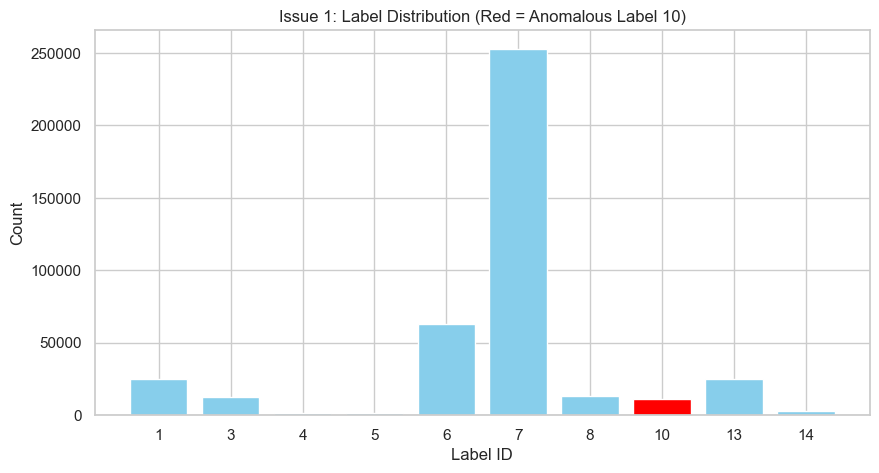


2. Detection of Extreme Outliers: Identification of Minimum Value -66.53974105170431 (back_x)


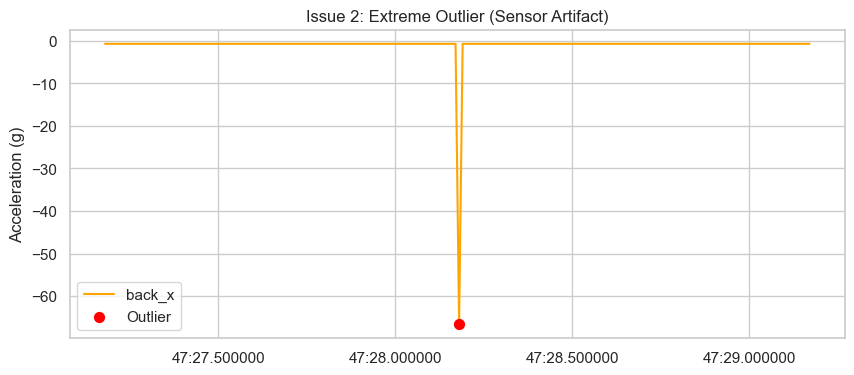


3. Data missing: 38 discontinuities detected > 0.05s
    Maximum interruption duration: 17.69 seconds


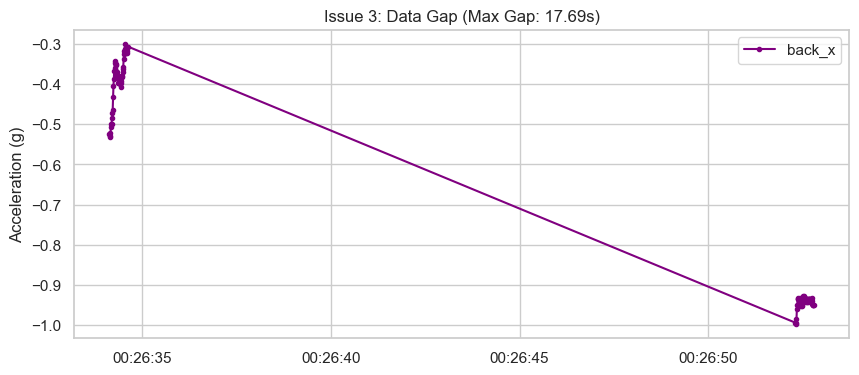


4. Sensor freeze: Variance of 6933 sample points approaches zero


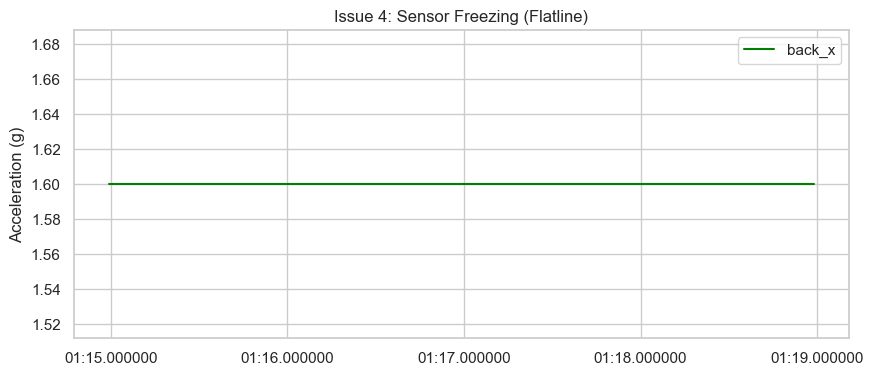

In [97]:
def analyze_s007_quality_fixed(file_path):
    # 1. Load data
    try:
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    print("--- S007 Data Quality Analysis Report ---")

    # --- Issue 1: Anomalous Label 10 ---
    label_counts = df['label'].value_counts().sort_index()
    print(f"\n1. Label Distribution:\n{label_counts}")

    plt.figure(figsize=(10, 5))
    # Convert index and data to numpy arrays for plotting
    x_labels = label_counts.index.astype(str).values
    y_values = label_counts.values
    colors = ['red' if x == '10' else 'skyblue' for x in x_labels]

    plt.bar(x_labels, y_values, color=colors)
    plt.title('Issue 1: Label Distribution (Red = Anomalous Label 10)')
    plt.xlabel('Label ID')
    plt.ylabel('Count')
    plt.show()

    # --- Issue 2: Extreme Outliers ---
    # Find the index of the minimum value in back_x
    min_idx = df['back_x'].idxmin()
    min_val = df.loc[min_idx, 'back_x']
    print(f"\n2. Detection of Extreme Outliers: Identification of Minimum Value {min_val} (back_x)")

    # Set display window
    start = max(0, min_idx - 100)
    end = min(len(df), min_idx + 100)
    subset_out = df.iloc[start:end]

    plt.figure(figsize=(10, 4))
    # Use .values
    plt.plot(subset_out['timestamp'].values, subset_out['back_x'].values, color='orange', label='back_x')
    # Use lists/arrays for scatter coordinates to ensure compatibility
    plt.scatter([df.iloc[min_idx]['timestamp']], [df.iloc[min_idx]['back_x']],
                color='red', s=50, label='Outlier', zorder=5)
    plt.title('Issue 2: Extreme Outlier (Sensor Artifact)')
    plt.ylabel('Acceleration (g)')
    plt.legend()
    plt.show()

    # --- Issue 3: Data Gaps ---
    df['time_diff'] = df['timestamp'].diff().dt.total_seconds()
    # Threshold > 0.05s (assuming 50Hz sampling rate, nominal diff is 0.02s)
    gaps = df[df['time_diff'] > 0.05]
    print(f"\n3. Data missing: {len(gaps)} discontinuities detected > 0.05s")

    if not gaps.empty:
        max_gap = df['time_diff'].max()
        print(f"    Maximum interruption duration: {max_gap:.2f} seconds")

        # Visualize the maximum interruption
        gap_idx = df['time_diff'].idxmax()
        start = max(0, gap_idx - 50)
        end = min(len(df), gap_idx + 50)
        subset_gap = df.iloc[start:end]

        plt.figure(figsize=(10, 4))
        # Use .values
        plt.plot(subset_gap['timestamp'].values, subset_gap['back_x'].values, '.-', color='purple', label='back_x')
        plt.title(f'Issue 3: Data Gap (Max Gap: {max_gap:.2f}s)')
        plt.ylabel('Acceleration (g)')
        plt.legend()
        plt.show()

    # --- Issue 4: Sensor Freezing ---
    # Calculate rolling standard deviation
    df['rolling_std'] = df['back_x'].rolling(window=50).std()
    # Find points where variance approaches zero (near-constant signal)
    freeze_points = df[df['rolling_std'] < 1e-6]
    print(f"\n4. Sensor freeze: Variance of {len(freeze_points)} sample points approaches zero")

    if not freeze_points.empty:
        # Find an index in the middle of the freeze section
        freeze_idx = freeze_points.index[len(freeze_points)//2]
        start = max(0, freeze_idx - 200)
        end = min(len(df), freeze_idx + 200)
        subset_freeze = df.iloc[start:end]

        plt.figure(figsize=(10, 4))
        # Use .values
        plt.plot(subset_freeze['timestamp'].values, subset_freeze['back_x'].values, color='green', label='back_x')
        plt.title('Issue 4: Sensor Freezing (Flatline)')
        plt.ylabel('Acceleration (g)')
        plt.legend()
        plt.show()

if __name__ == "__main__":
    # Ensure the path is correct or adjust it if necessary
    analyze_s007_quality_fixed('./MLT-CW-Dataset/S007.csv')

## 2.b Use deletion strategies for S007 data cleansing

In [98]:
def clean_s007_data(file_path):
    print("--- Starting S007 Dataset Cleaning ---")

    # 1. Load data
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    original_count = len(df)
    print(f"Original number of rows: {original_count}")

    # --- Step 1: Remove Anomalous Label 10 ---
    # Strategy: Directly delete all rows with label 10
    df_clean = df[df['label'] != 10].copy()
    rows_after_label = len(df_clean)
    print(f"1. Removed Anomalous Label 10: {original_count - rows_after_label} rows removed")

    # --- Step 2: Remove Sensor Freezing Data ---
    # Strategy: Delete rows where rolling standard deviation approaches 0 (window 50, approx. 0.5s)
    # Calculate the rolling standard deviation for back_x, fill NaN to prevent accidental removal of starting data
    rolling_std = df_clean['back_x'].rolling(window=50).std().fillna(1.0)
    # Keep non-frozen rows (standard deviation >= 1e-6)
    df_clean = df_clean[rolling_std >= 1e-6]
    rows_after_freeze = len(df_clean)
    print(f"2. Removed Sensor Freezing Segments: {rows_after_label - rows_after_freeze} rows removed")

    # --- Step 3: Remove Extreme Outliers ---
    # Strategy: Delete rows where acceleration on any axis exceeds 16g in absolute value
    sensor_cols = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']
    # Create mask: mark True if any value in the row is > 16 or < -16
    outlier_mask = (df_clean[sensor_cols].abs() > 16).any(axis=1)
    # Keep non-outlier values
    df_clean = df_clean[~outlier_mask]
    rows_after_outlier = len(df_clean)
    print(f"3. Removed Extreme Outliers (>16g): {rows_after_freeze - rows_after_outlier} rows removed")

    # --- Summary and Save ---
    final_count = len(df_clean)
    total_removed = original_count - final_count
    loss_ratio = (total_removed / original_count) * 100

    print(f"\n--- Cleaning Complete ---")
    print(f"Final number of rows: {final_count}")
    print(f"Total rows removed: {total_removed} ({loss_ratio:.2f}%)")

    # Save results
    output_file = './MLT-CW-Dataset/S007_cleaned.csv'
    df_clean.to_csv(output_file, index=False)
    print(f"Saved cleaned data to: {output_file}")

# Run the cleaning function
if __name__ == "__main__":
    clean_s007_data('./MLT-CW-Dataset//S007.csv')

--- Starting S007 Dataset Cleaning ---
Original number of rows: 408709
1. Removed Anomalous Label 10: 11290 rows removed
2. Removed Sensor Freezing Segments: 6933 rows removed
3. Removed Extreme Outliers (>16g): 32 rows removed

--- Cleaning Complete ---
Final number of rows: 390454
Total rows removed: 18255 (4.47%)
Saved cleaned data to: ./MLT-CW-Dataset/S007_cleaned.csv


## 2.c Generate sliding window 

In [99]:
def create_sliding_windows(final_df_merged, window_seconds=2, overlap_seconds=1, sampling_rate=100):
    """
    Converts continuous time-series data into sliding window segments.
    """
    print(f"--- Starting sliding window processing (Window: {window_seconds}s, Overlap: {overlap_seconds}s) ---")

    # 1. Calculate sample parameters
    window_size = int(window_seconds * sampling_rate)
    step_size = int((window_seconds - overlap_seconds) * sampling_rate)

    print(f"Sampling rate: {sampling_rate} Hz")
    print(f"Window size (samples): {window_size}, Step size (samples): {step_size}")

    # 2. Prepare feature columns
    feature_cols = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

    # Check for missing columns
    missing_cols = [col for col in feature_cols if col not in final_df_merged.columns]
    if missing_cols:
        print(f"Error: Missing feature columns in dataset: {missing_cols}")
        return None, None

    data_values = final_df_merged[feature_cols].values
    label_values = final_df_merged['label'].values

    # 3. Execute sliding window segmentation
    X = []
    y = []

    # This is an efficient loop that moves by the step size
    for i in range(0, len(final_df_merged) - window_size + 1, step_size):
        # Extract feature data for the current window (Example Shape: 200 x 6)
        window_data = data_values[i : i + window_size]

        # Extract labels for the current window
        window_labels = label_values[i : i + window_size]

        # vals are the unique values found (sorted), counts are their respective counts
        vals, counts = np.unique(window_labels, return_counts=True)
        # np.argmax returns the index of the first maximum count, combined with unique's sorting, returns the smallest mode label
        mode_label = vals[np.argmax(counts)]

        X.append(window_data)
        y.append(mode_label)

    # 4. Convert to Numpy arrays
    X = np.array(X)
    y = np.array(y)

    # 5. Report results
    print(f"\nProcessing complete!")
    print(f"Input data points: {len(final_df_merged)}")
    print(f"Generated window count (Data Points): {X.shape[0]}")
    print(f"Feature data shape (X): {X.shape} -> (num_windows, time_steps, num_features)")
    print(f"Label data shape (y): {y.shape}")

    return X, y

## ============ PART 1: Clean the training set and apply windowing ============

In [100]:
# Merge all cleaned training set csv files
train_paths = glob.glob(os.path.join(base_dir, "*.csv"))

# Filter: Exclude the original S007.csv, retain all other CSVs (including S007_cleaned.csv)
filtered_paths = [path for path in train_paths if "S007.csv" not in path]

# Batch read and merge data
df_list = [pd.read_csv(path) for path in filtered_paths]
final_df = pd.concat(df_list, ignore_index=True)

# Clean the training set after merging the S007_cleaned.csv file
final_df_deleted = drop_cycling_data(final_df)
final_df_merged = merge_stairs_data(final_df_deleted)
print(f"Number of merged files: {len(filtered_paths)}")
print(f"Final DataFrame shape: {final_df_merged.shape}")
train_df_cleaned = final_df_merged
train_df_cleaned

Original dataset size: 5550691 rows
Rows dropped: 498613
New dataset size: 5052078 rows
--- Before Merging ---
Original dataset size: 5052078 rows
Count of old stairs labels [4, 5]: 116336

--- After Merging ---
New dataset size: 5052078 rows (Should remain unchanged)
Count of new stairs label [9]: 116336

Result: Successfully merged 116336 samples.
Number of merged files: 18
Final DataFrame shape: (5052078, 10)


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,index,Unnamed: 0
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,NaN,NaN
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,NaN,NaN
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,NaN,NaN
3,2019-01-12 00:00:00.030,-0.648772,0.016579,-0.054284,-1.554248,-0.950978,-0.221140,6,NaN,NaN
4,2019-01-12 00:00:00.040,-0.355071,-0.051831,-0.113419,-0.547471,0.140903,-0.653782,6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
5550686,2019-01-12 00:55:45.780,-1.112549,-0.020752,-0.238281,-0.990234,0.067871,0.150146,3,NaN,NaN
5550687,2019-01-12 00:55:45.800,-1.163574,-0.036621,-0.275635,-1.096436,-0.043457,0.097168,3,NaN,NaN
5550688,2019-01-12 00:55:45.820,-1.278076,-0.054932,-0.315674,-1.230713,-0.177979,0.078125,3,NaN,NaN
5550689,2019-01-12 00:55:45.840,-1.360596,-0.058350,-0.342529,-1.265381,-0.165527,0.113281,3,NaN,NaN


In [102]:
# Training set windowing
if 'train_df_cleaned' in locals() and not train_df_cleaned.empty:
    # Call the function
    X_train, y_train = create_sliding_windows(train_df_cleaned)

    # Simple checks
    if X_train is not None:
        print("\nExample: Data shape of the first window:", X_train[0].shape)
        print("Example: The label of the first window:", y_train[0])
else:
    print("Note: Please load and clean the data (train_df_cleaned) before running this function.")

--- Starting sliding window processing (Window: 2s, Overlap: 1s) ---
Sampling rate: 100 Hz
Window size (samples): 200, Step size (samples): 100

Processing complete!
Input data points: 5052078
Generated window count (Data Points): 50519
Feature data shape (X): (50519, 200, 6) -> (num_windows, time_steps, num_features)
Label data shape (y): (50519,)

Example: Data shape of the first window: (200, 6)
Example: The label of the first window: 1


## ============ PART 2: Cleaning the test set and windowing ============

In [103]:
# Merge all cleaned test set csv files
test_paths = glob.glob(os.path.join(base_dir, "test-set", "*.csv"))

# Batch read and merge data
df_list = [pd.read_csv(path) for path in test_paths]
final_df = pd.concat(df_list, ignore_index=True)

# Clean the test set
final_df_deleted = drop_cycling_data(final_df)
final_df_merged = merge_stairs_data(final_df_deleted)
print(f"Number of merged files: {len(test_paths)}")
print(f"Final DataFrame shape: {final_df_merged.shape}")
test_df_cleaned = final_df_merged
test_df_cleaned

Original dataset size: 1122375 rows
Rows dropped: 16948
New dataset size: 1105427 rows
--- Before Merging ---
Original dataset size: 1105427 rows
Count of old stairs labels [4, 5]: 28732

--- After Merging ---
New dataset size: 1105427 rows (Should remain unchanged)
Count of new stairs label [9]: 28732

Result: Successfully merged 28732 samples.
Number of merged files: 4
Final DataFrame shape: (1105427, 9)


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,index
0,2019-01-12 00:00:00.000,-1.455469,0.199820,-0.000919,-0.658926,-0.369698,0.982122,6,NaN
1,2019-01-12 00:00:00.020,-0.969411,-0.113875,0.068938,-0.765164,0.839769,-0.646512,6,NaN
2,2019-01-12 00:00:00.040,-0.728391,0.000811,0.341911,-0.579921,0.306608,-0.523581,6,NaN
3,2019-01-12 00:00:00.060,-0.859020,0.222991,0.012635,-0.127765,-0.779781,-0.148429,6,NaN
4,2019-01-12 00:00:00.080,-0.561594,0.189641,0.098114,-0.809730,-0.222737,-0.392332,6,NaN
...,...,...,...,...,...,...,...,...,...
1122370,2019-01-12 00:57:18.900,-0.967773,-0.048584,-0.283936,-1.006104,-0.023438,-0.016357,6,NaN
1122371,2019-01-12 00:57:18.920,-0.984131,-0.032227,-0.264648,-1.000488,-0.071289,-0.010742,6,NaN
1122372,2019-01-12 00:57:18.940,-0.969727,-0.031006,-0.295410,-0.990967,-0.083496,0.015137,6,NaN
1122373,2019-01-12 00:57:18.960,-0.968506,-0.030029,-0.281494,-0.980469,-0.077881,0.054199,6,NaN


In [104]:
# Test set windowing
if 'test_df_cleaned' in locals() and not test_df_cleaned.empty:
    # Call the function
    X_test, y_test = create_sliding_windows(test_df_cleaned)

    # Simple checks
    if X_test is not None:
        print("\nExample: Data shape of the first window:", X_test[0].shape)
        print("Example: The label of the first window:", y_test[0])
else:
    # Corrected variable name in the error message for clarity
    print("Note: Please load and clean the data (test_df_cleaned) before running this function.")

--- Starting sliding window processing (Window: 2s, Overlap: 1s) ---
Sampling rate: 100 Hz
Window size (samples): 200, Step size (samples): 100

Processing complete!
Input data points: 1105427
Generated window count (Data Points): 11053
Feature data shape (X): (11053, 200, 6) -> (num_windows, time_steps, num_features)
Label data shape (y): (11053,)

Example: Data shape of the first window: (200, 6)
Example: The label of the first window: 6


# 3.a K-means

## =========== PART 1: Basic Utility Functions (ENMO) ============

In [105]:
def calculate_enmo(window_data):
    """
    Calculates ENMO (Euclidean Norm Minus One) to estimate the motion component,
    based on Reference [6].
    Formula: ENMO = max(0, ||a|| - 1)
    """
    # Extract back (first 3 columns) and thigh (last 3 columns) acceleration data
    back_acc = window_data[:, 0:3]
    thigh_acc = window_data[:, 3:6]

    # 1. Calculate the Euclidean Norm (Magnitude)
    norm_back = np.linalg.norm(back_acc, axis=1)
    norm_thigh = np.linalg.norm(thigh_acc, axis=1)

    # 2. Subtract the 1g gravity component and ensure non-negative (Ref [6])
    # Physical meaning: Removes static gravity, retaining only acceleration due to body motion
    enmo_back = np.maximum(0, norm_back - 1)
    enmo_thigh = np.maximum(0, norm_thigh - 1)

    return enmo_back, enmo_thigh


## =========== PART 2: Feature extraction (Baseline & Fine-Tuned) =========

In [106]:
def extract_features_baseline(X_windows):
    """
    Baseline: Establish a baseline with an initial set of 10 features.
    """
    print("--- Extracting Baseline Features (10 features) ---")
    features = []

    for window in X_windows:
        # 1. Calculate ENMO (Reference [6])
        enmo_back, enmo_thigh = calculate_enmo(window)

        # 2. Extract features (Total 10)
        sample_feats = [
            # --- ENMO Features (Reflects motion intensity) [4 features] ---
            np.mean(enmo_back), np.std(enmo_back),
            np.mean(enmo_thigh), np.std(enmo_thigh),

            # --- Raw Axis Features (Reflects posture/gravity direction) [6 features] ---
            # Select the most representative axes: Back X (Vertical), Back Z (Forward), Thigh X (Vertical)
            np.mean(window[:, 0]), np.std(window[:, 0]),  # Back X
            np.mean(window[:, 2]), np.std(window[:, 2]),  # Back Z
            np.mean(window[:, 3]), np.std(window[:, 3])   # Thigh X
        ]
        features.append(sample_feats)

    return np.array(features)

In [107]:
def extract_features_finetuned(X_windows):
    """
    b. Fine-Tuning: Improve over baseline (Max 20 features).
    New Features: Max, Min, Range, Energy (Signal Power)
    """
    print("--- Extracting Fine-Tuned Features (20 features) ---")
    features = []

    for window in X_windows:
        enmo_back, enmo_thigh = calculate_enmo(window)

        # Auxiliary calculation for Energy (Sum of squares / N)
        energy_back = np.sum(enmo_back**2) / len(enmo_back)
        energy_thigh = np.sum(enmo_thigh**2) / len(enmo_thigh)

        sample_feats = [
            # --- 1. Advanced ENMO Features (8 features) ---
            np.mean(enmo_back), np.std(enmo_back), np.max(enmo_back), energy_back,
            np.mean(enmo_thigh), np.std(enmo_thigh), np.max(enmo_thigh), energy_thigh,

            # --- 2. Raw Axis Statistical Features (12 features) ---
            # Calculate Mean and Std for all axes to capture full posture information
            # Back X, Y, Z
            np.mean(window[:, 0]), np.std(window[:, 0]),
            np.mean(window[:, 1]), np.std(window[:, 1]),
            np.mean(window[:, 2]), np.std(window[:, 2]),

            # Thigh X, Y, Z
            np.mean(window[:, 3]), np.std(window[:, 3]),
            np.mean(window[:, 4]), np.std(window[:, 4]),
            np.mean(window[:, 5]), np.std(window[:, 5])
        ]
        # Truncate to ensure no more than 20 features (currently exactly 20)
        features.append(sample_feats[:20])

    return np.array(features)

## ================= PART 3: K-means Pipeline Wrapper =================

In [108]:
class SemiSupervisedKMeans:
    def __init__(self, n_clusters, random_state=42):
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        self.scaler = StandardScaler()
        self.cluster_to_label_map = {}

    def fit(self, X, y):
        # 1. Fit the Scaler (only on the training set)
        X_scaled = self.scaler.fit_transform(X)

        # 2. Fit K-Means
        clusters = self.kmeans.fit_predict(X_scaled)

        # 3. Establish the Mapping (Cluster -> Label)
        self.cluster_to_label_map = {}
        unique_clusters = np.unique(clusters)
        for cluster_id in unique_clusters:
            labels_in_cluster = y[clusters == cluster_id]
            if len(labels_in_cluster) > 0:
                # Determine the majority label (mode) for this cluster
                vals, counts = np.unique(labels_in_cluster, return_counts=True)
                majority_label = vals[np.argmax(counts)]
                self.cluster_to_label_map[cluster_id] = majority_label
            else:
                # Handle empty cluster case
                self.cluster_to_label_map[cluster_id] = -1
        return self

    def predict(self, X):
        # Crucial: Use the Scaler fitted on the training set for transformation
        X_scaled = self.scaler.transform(X)
        clusters = self.kmeans.predict(X_scaled)
        # Map cluster IDs to their majority label, using -1 for unmapped/empty clusters
        return np.array([self.cluster_to_label_map.get(c, -1) for c in clusters])

## ========== PART 4: Assessment and Reporting (Evaluation Loop) ==========

In [109]:
def train_and_evaluate(X_train, y_train, X_test, y_test, mode="Baseline"):
    print(f"\n{'#'*60}")
    print(f"### RUNNING MODEL MODE: {mode}")
    print(f"{'#'*60}")

    # --- Step 1: Feature Extraction ---
    if mode == "Baseline":
        X_train_feats = extract_features_baseline(X_train)
        X_test_feats = extract_features_baseline(X_test)
        n_clusters = len(np.unique(y_train))
        print(f"Config: 10 Features | K = {n_clusters} (Same as classes)")
    else: # Fine-Tuned
        X_train_feats = extract_features_finetuned(X_train)
        X_test_feats = extract_features_finetuned(X_test)
        n_clusters = len(np.unique(y_train)) * 2
        print(f"Config: 20 Features | K = {n_clusters} (Over-clustering)")

    # --- Step 2: Cross-Validation (Calculate both training and validation error) ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize lists
    train_scores = []
    train_recalls = []
    cv_scores = []
    cv_recalls = []

    for train_idx, val_idx in skf.split(X_train_feats, y_train):
        X_fold_train, X_fold_val = X_train_feats[train_idx], X_train_feats[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model = SemiSupervisedKMeans(n_clusters=n_clusters)
        model.fit(X_fold_train, y_fold_train)

        # --- Calculate Training Set Performance ---
        y_pred_train = model.predict(X_fold_train)
        train_acc = accuracy_score(y_fold_train, y_pred_train)
        train_rec = recall_score(y_fold_train, y_pred_train, average='macro', zero_division=0)
        train_scores.append(train_acc)
        train_recalls.append(train_rec)

        # --- Calculate Validation Set Performance ---
        y_pred_val = model.predict(X_fold_val)
        val_acc = accuracy_score(y_fold_val, y_pred_val)
        val_rec = recall_score(y_fold_val, y_pred_val, average='macro', zero_division=0)
        cv_scores.append(val_acc)
        cv_recalls.append(val_rec)

    # Save average training accuracy for Phase 4 use
    avg_train_acc = np.mean(train_scores)

    # >>> Phase 1: Training Performance
    print(f"\n>>> Phase 1: Training Performance (Avg across 5-Folds)")
    print(f"Average Training Accuracy: {avg_train_acc:.4f}")
    print(f"Average Training Recall:   {np.mean(train_recalls):.4f}")

    # >>> Phase 2: Validation Performance
    print(f"\n>>> Phase 2: Validation Performance (Avg across 5-Folds)")
    print(f"Average CV Accuracy:         {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
    print(f"Average CV Recall:           {np.mean(cv_recalls):.4f}")

    if avg_train_acc - np.mean(cv_scores) > 0.15:
        print("Warning: High variance detected. Model may be overfitting.")

    # --- Step 3: Train on full training set, evaluate on test set (Final Test) ---
    print(f"\n>>> Phase 3: Final Test Performance")

    final_model = SemiSupervisedKMeans(n_clusters=n_clusters)
    final_model.fit(X_train_feats, y_train)

    y_test_pred = final_model.predict(X_test_feats)

    report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    final_test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)

    # Save test accuracy for Phase 4 use
    final_test_acc = report_dict['accuracy']

    print(f"Final Test Accuracy:         {final_test_acc:.4f}")
    print(f"Final Test Recall:           {final_test_recall:.4f}")

    # --- Phase 4: Error Analysis and Generalization Gap ---
    print(f"\n>>> Phase 4: Error Analysis (Calculations)")

    train_error = 1 - avg_train_acc
    gen_error = 1 - final_test_acc
    gen_gap = avg_train_acc - final_test_acc

    # Output in the required format
    print(f"Training error= 1 - {avg_train_acc:.4f} = {train_error:.4f}")
    print(f"Generalisation error = 1 -{final_test_acc:.4f} = {gen_error:.4f}")
    print(f"Generalisation gap = {avg_train_acc:.4f} - {final_test_acc:.4f} = {gen_gap:.4f}")

    # --- Step 4: Generate Results Table ---
    label_map = {1: 'Walking', 2: 'Running', 3: 'Shuffling', 6: 'Standing', 7: 'Sitting', 8: 'Lying', 9: 'Stairs'}
    table_data = []
    unique_classes = sorted([c for c in np.unique(y_test) if str(c) in report_dict])

    for cls in unique_classes:
        cls_str = str(cls)
        p = report_dict[cls_str]['precision']
        r = report_dict[cls_str]['recall']
        status = "PASS" if (p >= 0.75 and r >= 0.50) else "FAIL"

        table_data.append({
            "Label": cls,
            "Activity": label_map.get(cls, str(cls)),
            "Precision": f"{p:.2%}",
            "Recall": f"{r:.2%}",
            "Status": status
        })

    df_results = pd.DataFrame(table_data)
    print("\n" + df_results.to_string(index=False))

    # --- Step 5: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_classes, yticklabels=unique_classes)
    plt.title(f'Confusion Matrix - {mode} (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return final_test_acc

## ================= Part 5: Main execution block =================

>>> Data Preparation...
--- Starting sliding window processing (Window: 2s, Overlap: 1s) ---
Sampling rate: 100 Hz
Window size (samples): 200, Step size (samples): 100

Processing complete!
Input data points: 5052078
Generated window count (Data Points): 50519
Feature data shape (X): (50519, 200, 6) -> (num_windows, time_steps, num_features)
Label data shape (y): (50519,)
--- Starting sliding window processing (Window: 2s, Overlap: 1s) ---
Sampling rate: 100 Hz
Window size (samples): 200, Step size (samples): 100

Processing complete!
Input data points: 1105427
Generated window count (Data Points): 11053
Feature data shape (X): (11053, 200, 6) -> (num_windows, time_steps, num_features)
Label data shape (y): (11053,)
Training Windows: (50519, 200, 6)
Testing Windows:  (11053, 200, 6)

############################################################
### RUNNING MODEL MODE: Baseline
############################################################
--- Extracting Baseline Features (10 features) ---

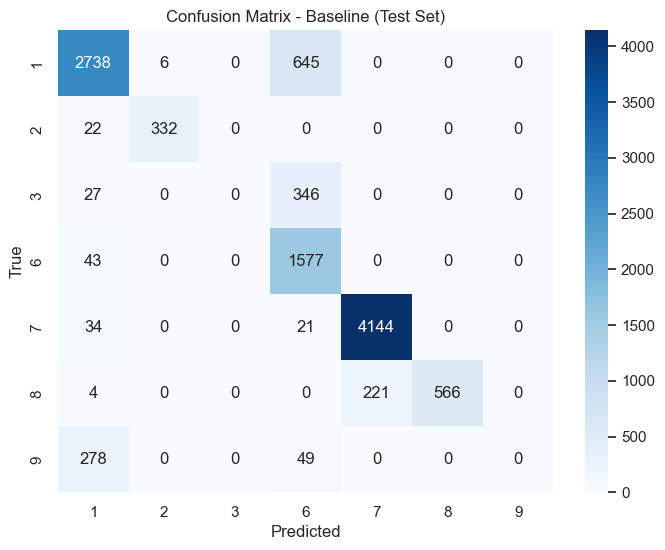


############################################################
### RUNNING MODEL MODE: Fine-Tuned
############################################################
--- Extracting Fine-Tuned Features (20 features) ---
--- Extracting Fine-Tuned Features (20 features) ---
Config: 20 Features | K = 14 (Over-clustering)

>>> Phase 1: Training Performance (Avg across 5-Folds)
Average Training Accuracy: 0.8869
Average Training Recall:   0.6463

>>> Phase 2: Validation Performance (Avg across 5-Folds)
Average CV Accuracy:         0.8872 (+/- 0.0038)
Average CV Recall:           0.6466

>>> Phase 3: Final Test Performance
Final Test Accuracy:         0.8769
Final Test Recall:           0.6498

>>> Phase 4: Error Analysis (Calculations)
Training error= 1 - 0.8869 = 0.1131
Generalisation error = 1 -0.8769 = 0.1231
Generalisation gap = 0.8869 - 0.8769 = 0.0100

 Label  Activity Precision Recall Status
     1   Walking    84.48% 95.07%   PASS
     2   Running    97.71% 96.33%   PASS
     3 Shuffling     

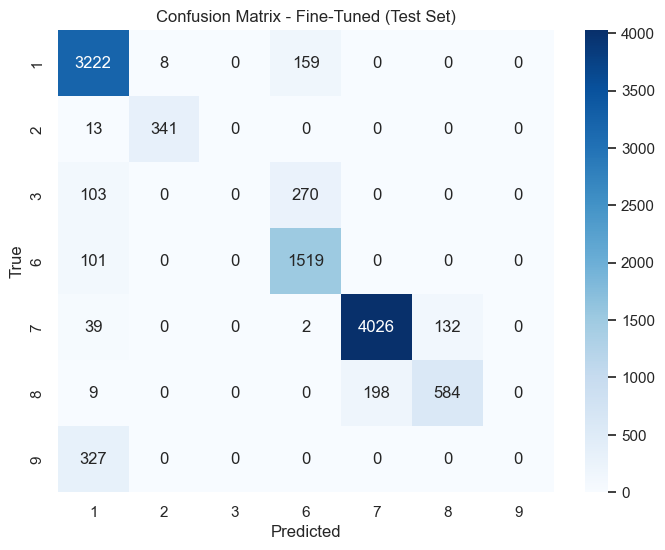

In [110]:
if 'train_df_cleaned' in locals() and 'test_df_cleaned' in locals():
    print(">>> Data Preparation...")

    # 1. Apply windowing to Train and Test sets separately
    X_train_wins, y_train = create_sliding_windows(train_df_cleaned)
    X_test_wins, y_test = create_sliding_windows(test_df_cleaned)

    print(f"Training Windows: {X_train_wins.shape}")
    print(f"Testing Windows:  {X_test_wins.shape}")

    if len(X_train_wins) > 0 and len(X_test_wins) > 0:
        # 2. Run Baseline Model
        acc_baseline = train_and_evaluate(X_train_wins, y_train, X_test_wins, y_test, mode="Baseline")

        # 3. Run Fine-Tuned Model
        acc_finetuned = train_and_evaluate(X_train_wins, y_train, X_test_wins, y_test, mode="Fine-Tuned")
else:
    print("Error: Dataframes 'train_df_cleaned' and 'test_df_cleaned' not found.")

# 3.b Random forest

## ==========  Part1:Model Training and Evaluation Pipeline ==========


In [111]:
def run_rf_evaluation(X_train_raw, y_train, X_test_raw, y_test, mode="Baseline"):
    print(f"\n{'#'*60}")
    print(f"### RUNNING MODEL MODE: {mode}")
    print(f"{'#'*60}")

    # --- Step 1: Feature Extraction ---
    print(f"--- Extracting {mode} Features... ---")

    if mode == "Baseline":
        X_train_feats = extract_features_baseline(X_train_raw)
        X_test_feats = extract_features_baseline(X_test_raw)
        # RF Configuration Description
        print(f"Config: 10 Features | n_estimators=50 (Basic Setup)")
        clf = RandomForestClassifier(n_estimators=50, random_state=42)
    else:
        X_train_feats = extract_features_finetuned(X_train_raw)
        X_test_feats = extract_features_finetuned(X_test_raw)
        print(f"Config: Fine-Tuned Features | n_estimators=200, Balanced Weights")
        clf = RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

    # --- Step 2: Cross-Validation (Calculate Training and Validation simultaneously) ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize storage lists
    train_scores = []
    train_recalls = []
    cv_scores = []
    cv_recalls = []

    for train_idx, val_idx in skf.split(X_train_feats, y_train):
        X_t, X_v = X_train_feats[train_idx], X_train_feats[val_idx]
        y_t, y_v = y_train[train_idx], y_train[val_idx]

        clf.fit(X_t, y_t)

        # 1. Calculate Training Set Performance (for Phase 1)
        y_t_pred = clf.predict(X_t)
        train_scores.append(accuracy_score(y_t, y_t_pred))
        train_recalls.append(recall_score(y_t, y_t_pred, average='macro', zero_division=0))

        # 2. Calculate Validation Set Performance (for Phase 2)
        y_v_pred = clf.predict(X_v)
        cv_scores.append(accuracy_score(y_v, y_v_pred))
        cv_recalls.append(recall_score(y_v, y_v_pred, average='macro', zero_division=0))

    # Calculate means
    avg_train_acc = np.mean(train_scores)
    avg_train_rec = np.mean(train_recalls)
    avg_cv_acc = np.mean(cv_scores)
    avg_cv_rec = np.mean(cv_recalls)
    cv_std = np.std(cv_scores)

    # >>> Phase 1: Training Performance
    print(f"\n>>> Phase 1: Training Performance (Avg across 5-Folds)")
    print(f"Average Training Accuracy: {avg_train_acc:.4f}")
    print(f"Average Training Recall:   {avg_train_rec:.4f}")

    # >>> Phase 2: Validation Performance
    print(f"\n>>> Phase 2: Validation Performance (Avg across 5-Folds)")
    print(f"Average CV Accuracy:         {avg_cv_acc:.4f} (+/- {cv_std:.4f})")
    print(f"Average CV Recall:           {avg_cv_rec:.4f}")

    # --- Step 3: Final Test ---
    clf.fit(X_train_feats, y_train)
    y_test_pred = clf.predict(X_test_feats)

    final_test_acc = accuracy_score(y_test, y_test_pred)
    final_test_rec = recall_score(y_test, y_test_pred, average='macro', zero_division=0)

    # >>> Phase 3: Final Test Performance
    print(f"\n>>> Phase 3: Final Test Performance")
    print(f"Final Test Accuracy:         {final_test_acc:.4f}")
    print(f"Final Test Recall:           {final_test_rec:.4f}")

    # --- Step 4: Error Analysis ---
    # >>> Phase 4: Error Analysis
    print(f"\n>>> Phase 4: Error Analysis (Calculations)")

    train_error = 1 - avg_train_acc
    gen_error = 1 - final_test_acc
    gen_gap = avg_train_acc - final_test_acc

    print(f"Training error= 1 - {avg_train_acc:.4f} = {train_error:.4f}")
    print(f"Generalisation error = 1 - {final_test_acc:.4f} = {gen_error:.4f}")
    print(f"Generalisation gap = {avg_train_acc:.4f} - {final_test_acc:.4f} = {gen_gap:.4f}")

    # --- Step 5: Generate Results Table ---
    label_map = {1: 'Walking', 2: 'Running', 3: 'Shuffling', 6: 'Standing', 7: 'Sitting', 8: 'Lying', 9: 'Stairs'}
    report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)

    table_data = []
    unique_classes = sorted([c for c in np.unique(y_test) if str(c) in report_dict])

    for cls in unique_classes:
        cls_str = str(cls)
        p = report_dict[cls_str]['precision']
        r = report_dict[cls_str]['recall']

        # Evaluation criteria
        status = "PASS" if (p >= 0.75 and r >= 0.50) else "FAIL"

        table_data.append({
            "Label": cls,
            "Activity": label_map.get(cls, str(cls)),
            "Precision": f"{p:.2%}",
            "Recall": f"{r:.2%}",
            "Status": status
        })

    df_results = pd.DataFrame(table_data)
    # Print table
    print("\n" + df_results.to_string(index=False))

    # --- Step 6: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=[label_map.get(c,c) for c in unique_classes],
                yticklabels=[label_map.get(c,c) for c in unique_classes])
    plt.title(f'Confusion Matrix - {mode} (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return df_results

## =================Part2: Main execution block =================

>>> Data Preparation...
--- Starting sliding window processing (Window: 2s, Overlap: 1s) ---
Sampling rate: 100 Hz
Window size (samples): 200, Step size (samples): 100

Processing complete!
Input data points: 5052078
Generated window count (Data Points): 50519
Feature data shape (X): (50519, 200, 6) -> (num_windows, time_steps, num_features)
Label data shape (y): (50519,)
--- Starting sliding window processing (Window: 2s, Overlap: 1s) ---
Sampling rate: 100 Hz
Window size (samples): 200, Step size (samples): 100

Processing complete!
Input data points: 1105427
Generated window count (Data Points): 11053
Feature data shape (X): (11053, 200, 6) -> (num_windows, time_steps, num_features)
Label data shape (y): (11053,)
Training Windows: (50519, 200, 6)
Testing Windows:  (11053, 200, 6)

############################################################
### RUNNING MODEL MODE: Baseline
############################################################
--- Extracting Baseline Features... ---
--- Extrac

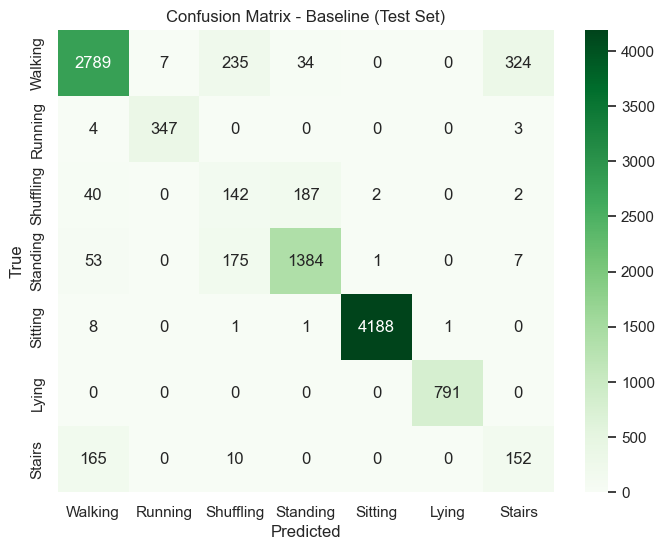


############################################################
### RUNNING MODEL MODE: Fine-Tuned
############################################################
--- Extracting Fine-Tuned Features... ---
--- Extracting Fine-Tuned Features (20 features) ---
--- Extracting Fine-Tuned Features (20 features) ---
Config: Fine-Tuned Features | n_estimators=200, Balanced Weights

>>> Phase 1: Training Performance (Avg across 5-Folds)
Average Training Accuracy: 1.0000
Average Training Recall:   1.0000

>>> Phase 2: Validation Performance (Avg across 5-Folds)
Average CV Accuracy:         0.9513 (+/- 0.0007)
Average CV Recall:           0.8644

>>> Phase 3: Final Test Performance
Final Test Accuracy:         0.9176
Final Test Recall:           0.8203

>>> Phase 4: Error Analysis (Calculations)
Training error= 1 - 1.0000 = 0.0000
Generalisation error = 1 - 0.9176 = 0.0824
Generalisation gap = 1.0000 - 0.9176 = 0.0824

 Label  Activity Precision Recall Status
     1   Walking    92.19% 88.11%   PASS
 

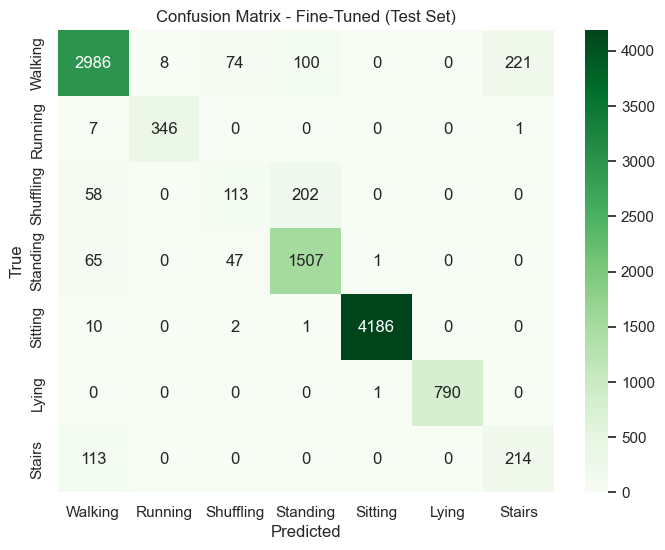

In [112]:
if 'train_df_cleaned' in locals() and 'test_df_cleaned' in locals():
    print(">>> Data Preparation...")

    # 1. Apply windowing to Train and Test sets separately
    X_train_wins, y_train = create_sliding_windows(train_df_cleaned)
    X_test_wins, y_test = create_sliding_windows(test_df_cleaned)

    print(f"Training Windows: {X_train_wins.shape}")
    print(f"Testing Windows:  {X_test_wins.shape}")

    if len(X_train_wins) > 0 and len(X_test_wins) > 0:
        # 2. Run Baseline Model
        df_baseline = run_rf_evaluation(X_train_wins, y_train, X_test_wins, y_test, mode="Baseline")

        # 3. Run Fine-Tuned Model
        df_finetuned = run_rf_evaluation(X_train_wins, y_train, X_test_wins, y_test, mode="Fine-Tuned")

    else:
        print("Error: Sliding window generation returned empty arrays.")
else:
    print("Error: Dataframes 'train_df_cleaned' and 'test_df_cleaned' not found.")

# 3.c CNN

In [113]:
# Set a random seed to ensure reproducible results
np.random.seed(42)

# TensorFlow 2.x
tf.random.set_seed(42)


## ========== PART 1: Data Preprocessing and Windowisation ==========


In [114]:
def create_cnn_windows(df, window_seconds=2, overlap_seconds=1, sampling_rate=100):
    """
    Creates 3D window data for a CNN.
    In addition to the 6 original axes, 2 additional ENMO channels are concatenated.
    Input Shape: (N_samples, Time_Steps, Channels) -> (N, 200, 8)
    """
    print(f"Creating CNN windows (Size={window_seconds}s, Overlap={overlap_seconds}s)...")
    window_size = int(window_seconds * sampling_rate)
    step_size = int((window_seconds - overlap_seconds) * sampling_rate)

    # Original 6 axes
    feature_cols = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

    # Check for columns
    if not all(col in df.columns for col in feature_cols):
        print("Error: Missing sensor columns.")
        return np.array([]), np.array([])

    data_values = df[feature_cols].values
    label_values = df['label'].values

    X = []
    y = []

    for i in range(0, len(df) - window_size + 1, step_size):
        # 1. Get the raw window (200, 6)
        raw_window = data_values[i : i + window_size]

        # 2. Calculate additional features (ENMO) - Transformation Step
        enmo_b, enmo_t = calculate_enmo(raw_window)

        # 3. Concatenate features: Add ENMO as additional Channels
        enmo_b = enmo_b.reshape(-1, 1)
        enmo_t = enmo_t.reshape(-1, 1)

        # Final Shape (200, 8) -> [Bx, By, Bz, B_ENMO, Tx, Ty, Tz, T_ENMO]
        augmented_window = np.hstack((raw_window, enmo_b, enmo_t))

        # Label processing (get the mode/majority label)
        labels = label_values[i : i + window_size]
        vals, counts = np.unique(labels, return_counts=True)
        mode_label = vals[np.argmax(counts)]

        X.append(augmented_window)
        y.append(mode_label)

    return np.array(X), np.array(y)

## ===========PART 2: CNN Model Architecture (Baseline & Fine-Tuned) ==========


In [115]:
def build_baseline_cnn(input_shape, num_classes):
    """
    Baseline: Simple Shallow Network
    """
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(filters=16, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_finetuned_cnn(input_shape, num_classes):
    """
    Fine-Tuned: 
    1. Deeper Architecture (3 Blocks) for feature hierarchy.
    2. BatchNormalization for faster convergence and stability.
    3. GlobalAveragePooling1D to reduce parameters and overfitting (vs Flatten).
    4. Dropout to improve generalization on Test set.
    """
    model = Sequential([
        Input(shape=input_shape),
        
        # Block 1
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Block 2
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Block 3
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(), # Replaces Flatten
        
        # Dense
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    
    # Reduce the learning rate in conjunction with the Scheduler
    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## ========== PART 3: Training and Evaluation Pipeline (Cross-Validation) ========

In [129]:
def run_cnn_evaluation(X_train, y_train, X_test, y_test, mode="Baseline"):
    print(f"\n{'#'*60}")
    print(f"### RUNNING MODEL MODE: {mode}")
    print(f"{'#'*60}")

    # --- Step 1: Label Encoding & Prep ---
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)

    # Ensure test labels are valid
    try:
        y_test_enc = le.transform(y_test)
    except ValueError:
        valid_mask = np.isin(y_test, le.classes_)
        X_test = X_test[valid_mask]
        y_test = y_test[valid_mask]
        y_test_enc = le.transform(y_test)

    num_classes = len(le.classes_)
    y_train_cat = to_categorical(y_train_enc, num_classes)
    y_test_cat = to_categorical(y_test_enc, num_classes)

    # Simulate concise configuration output
    print(f"--- Configuration: {mode} ---")
    if mode == "Baseline":
        epochs = 10
        batch_size = 64
        class_weights = None
        callbacks = []
        print(f"Config: Epochs={epochs}, Batch={batch_size}, No Class Weights")
    else:
        epochs = 30
        batch_size = 32

        # Compute balanced class weights
        from sklearn.utils.class_weight import compute_class_weight
        weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
        class_weights = dict(enumerate(weights))

        # Define callbacks
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
        callbacks = [es, lr_scheduler]
        print(f"Config: Epochs={epochs}, Class Weights=Balanced, EarlyStopping=True")

    # --- Step 2: Cross-Validation (Calculate Training and Validation simultaneously) ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize storage lists
    train_scores = []
    train_recalls = []
    cv_scores = []
    cv_recalls = []

    cv_epochs = 5 if mode == "Baseline" else 10 # Faster CV for speed

    for t_idx, v_idx in skf.split(X_train, y_train_enc):
        X_t, X_v = X_train[t_idx], X_train[v_idx]
        y_t, y_v = y_train_cat[t_idx], y_train_cat[v_idx]

        # Build Model
        if mode == "Baseline":
            # Assuming input_shape is fixed to (window_size, 8) based on create_cnn_windows
            model = build_baseline_cnn(input_shape=(X_train.shape[1], 8), num_classes=num_classes)
        else:
            model = build_finetuned_cnn(input_shape=(X_train.shape[1], 8), num_classes=num_classes)

        # Fit
        model.fit(X_t, y_t, epochs=cv_epochs, batch_size=batch_size,
                  verbose=0, class_weight=class_weights)

        # --- 1. Calculate Training Set Performance (for Phase 1) ---
        # Evaluate returns [loss, accuracy]
        train_acc = model.evaluate(X_t, y_t, verbose=0)[1]

        # Predict for Recall
        y_t_pred_prob = model.predict(X_t, verbose=0)
        y_t_pred = np.argmax(y_t_pred_prob, axis=1)
        y_t_true = np.argmax(y_t, axis=1)
        train_rec = recall_score(y_t_true, y_t_pred, average='macro', zero_division=0)

        train_scores.append(train_acc)
        train_recalls.append(train_rec)

        # --- 2. Calculate Validation Set Performance (for Phase 2) ---
        val_acc = model.evaluate(X_v, y_v, verbose=0)[1]

        y_v_pred_prob = model.predict(X_v, verbose=0)
        y_v_pred = np.argmax(y_v_pred_prob, axis=1)
        y_v_true = np.argmax(y_v, axis=1)
        val_rec = recall_score(y_v_true, y_v_pred, average='macro', zero_division=0)

        cv_scores.append(val_acc)
        cv_recalls.append(val_rec)

    # Calculate means
    avg_train_acc = np.mean(train_scores)
    avg_train_rec = np.mean(train_recalls)
    avg_cv_acc = np.mean(cv_scores)
    avg_cv_rec = np.mean(cv_recalls)
    cv_std = np.std(cv_scores)

    # >>> Phase 1: Training Performance
    print(f"\n>>> Phase 1: Training Performance (Avg across 5-Folds)")
    print(f"Average Training Accuracy: {avg_train_acc:.4f}")
    print(f"Average Training Recall:   {avg_train_rec:.4f}")

    # >>> Phase 2: Validation Performance
    print(f"\n>>> Phase 2: Validation Performance (Avg across 5-Folds)")
    print(f"Average CV Accuracy:         {avg_cv_acc:.4f} (+/- {cv_std:.4f})")
    print(f"Average CV Recall:           {avg_cv_rec:.4f}")

    # --- Step 3: Final Test ---
    if mode == "Baseline":
        final_model = build_baseline_cnn(input_shape=(X_train.shape[1], 8), num_classes=num_classes)
    else:
        final_model = build_finetuned_cnn(input_shape=(X_train.shape[1], 8), num_classes=num_classes)

    # Capture history object
    history = final_model.fit(
        X_train, y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test_cat),
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=0
    )

    y_pred_probs = final_model.predict(X_test, verbose=0)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)

    final_test_acc = accuracy_score(y_test_enc, y_pred_idx)
    final_test_rec = recall_score(y_test_enc, y_pred_idx, average='macro', zero_division=0)

    # >>> Phase 3: Final Test Performance
    print(f"\n>>> Phase 3: Final Test Performance")
    print(f"Final Test Accuracy:         {final_test_acc:.4f}")
    print(f"Final Test Recall:           {final_test_rec:.4f}")

    # --- Step 4: Error Analysis ---
    # >>> Phase 4: Error Analysis
    print(f"\n>>> Phase 4: Error Analysis (Calculations)")

    train_error = 1 - avg_train_acc
    gen_error = 1 - final_test_acc
    gen_gap = avg_train_acc - final_test_acc

    print(f"Training error= 1 - {avg_train_acc:.4f} = {train_error:.4f}")
    print(f"Generalisation error = 1 - {final_test_acc:.4f} = {gen_error:.4f}")
    print(f"Generalisation gap = {avg_train_acc:.4f} - {final_test_acc:.4f} = {gen_gap:.4f}")

    # --- Step 5: Generate Results Table ---
    label_map = {1: 'Walking', 2: 'Running', 3: 'Shuffling', 6: 'Standing', 7: 'Sitting', 8: 'Lying', 9: 'Stairs'}
    report_dict = classification_report(y_test_enc, y_pred_idx, output_dict=True, zero_division=0)

    table_data = []
    unique_classes_in_test = sorted(np.unique(y_test_enc))

    for cls_idx in unique_classes_in_test:
        cls_original = le.classes_[cls_idx]
        cls_str = str(cls_idx)

        if cls_str in report_dict:
            precision = report_dict[cls_str]['precision']
            recall = report_dict[cls_str]['recall']

            status = "PASS" if (precision >= 0.75 and recall >= 0.50) else "FAIL"

            table_data.append({
                "Label": cls_original,
                "Activity": label_map.get(cls_original, str(cls_original)),
                "Precision": f"{precision:.2%}",
                "Recall": f"{recall:.2%}",
                "Status": status
            })

    df_results = pd.DataFrame(table_data)
    print("\n" + df_results.to_string(index=False))

    # Step 5.5: Plot Learning Curves ---
    plt.figure(figsize=(12, 5))

    # Subplot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc', marker='.')
    plt.plot(history.history['val_accuracy'], label='Test Acc', marker='.')
    plt.title(f'Model Accuracy - {mode}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', marker='.')
    plt.plot(history.history['val_loss'], label='Test Loss', marker='.')
    plt.title(f'Model Loss - {mode}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # --- Step 6: Confusion Matrix ---
    cm = confusion_matrix(y_test_enc, y_pred_idx)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=[label_map.get(c, c) for c in le.classes_],
                yticklabels=[label_map.get(c, c) for c in le.classes_])
    plt.title(f'Confusion Matrix - {mode} (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return df_results, final_test_acc, final_test_rec

## ================= Part4: Main execution block =================

>>> Data Preparation...
Creating CNN windows (Size=2s, Overlap=1s)...
Creating CNN windows (Size=2s, Overlap=1s)...
Training Windows: (50519, 200, 8)
Testing Windows:  (11053, 200, 8)

############################################################
### RUNNING MODEL MODE: Baseline
############################################################
--- Configuration: Baseline ---
Config: Epochs=10, Batch=64, No Class Weights

>>> Phase 1: Training Performance (Avg across 5-Folds)
Average Training Accuracy: 0.9513
Average Training Recall:   0.8656

>>> Phase 2: Validation Performance (Avg across 5-Folds)
Average CV Accuracy:         0.9385 (+/- 0.0016)
Average CV Recall:           0.8298

>>> Phase 3: Final Test Performance
Final Test Accuracy:         0.8625
Final Test Recall:           0.8361

>>> Phase 4: Error Analysis (Calculations)
Training error= 1 - 0.9513 = 0.0487
Generalisation error = 1 - 0.8625 = 0.1375
Generalisation gap = 0.9513 - 0.8625 = 0.0888

 Label  Activity Precision Recall St

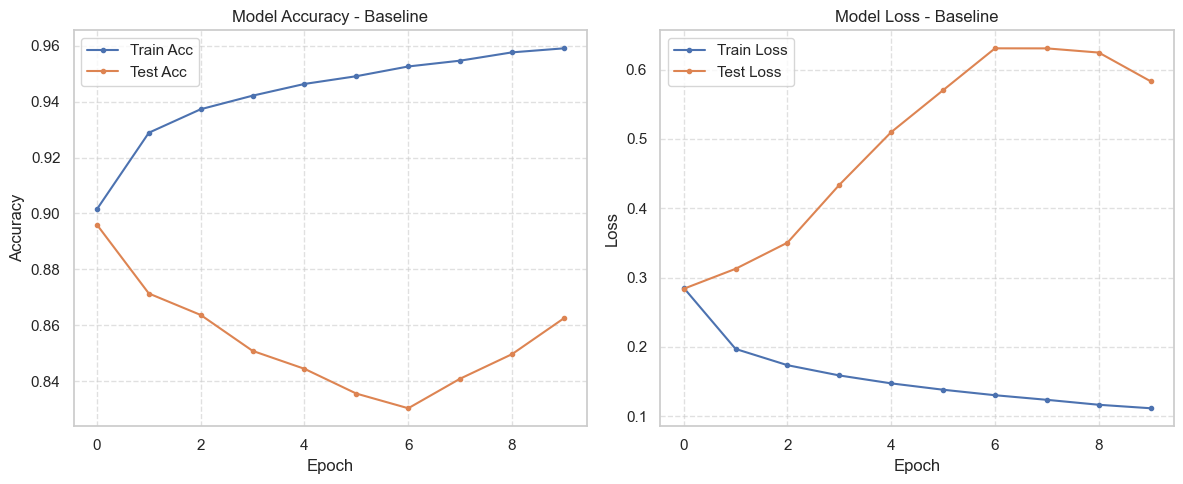

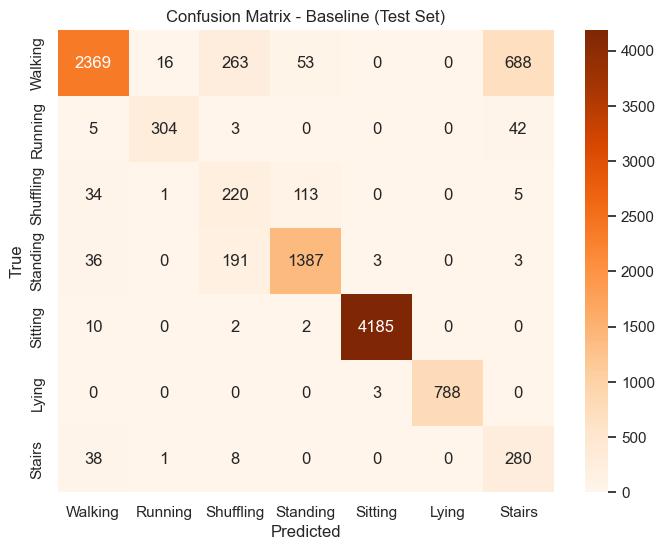


############################################################
### RUNNING MODEL MODE: Fine-Tuned
############################################################
--- Configuration: Fine-Tuned ---
Config: Epochs=30, Class Weights=Balanced, EarlyStopping=True

>>> Phase 1: Training Performance (Avg across 5-Folds)
Average Training Accuracy: 0.9392
Average Training Recall:   0.9110

>>> Phase 2: Validation Performance (Avg across 5-Folds)
Average CV Accuracy:         0.9363 (+/- 0.0055)
Average CV Recall:           0.9040

>>> Phase 3: Final Test Performance
Final Test Accuracy:         0.8242
Final Test Recall:           0.8094

>>> Phase 4: Error Analysis (Calculations)
Training error= 1 - 0.9392 = 0.0608
Generalisation error = 1 - 0.8242 = 0.1758
Generalisation gap = 0.9392 - 0.8242 = 0.1150

 Label  Activity Precision Recall Status
     1   Walking    99.51% 59.46%   PASS
     2   Running    98.38% 85.88%   PASS
     3 Shuffling    18.83% 57.91%   FAIL
     6  Standing    89.09% 84.69%   

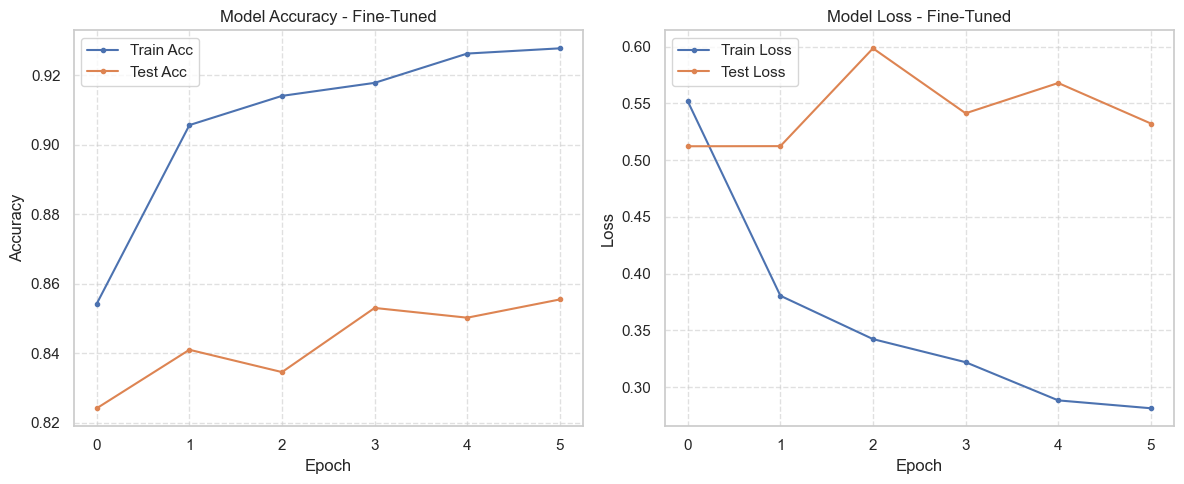

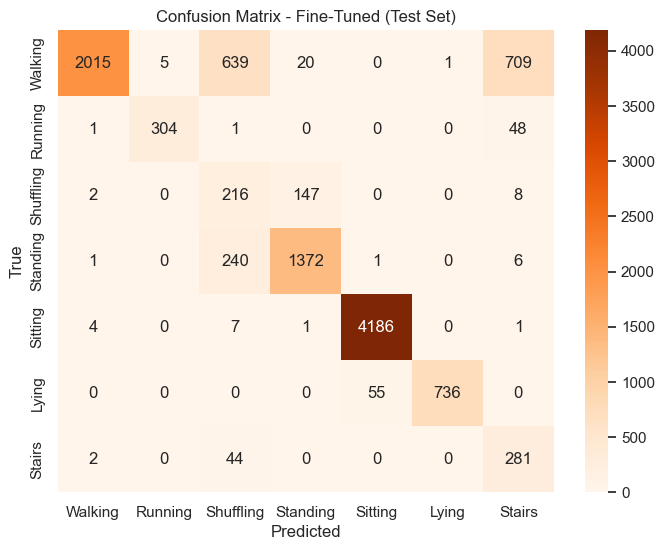

In [130]:
if 'train_df_cleaned' in locals() and 'test_df_cleaned' in locals():
    print(">>> Data Preparation...")

    # 1. Apply windowing to Train and Test sets separately
    X_train_cnn, y_train_cnn = create_cnn_windows(train_df_cleaned)
    X_test_cnn, y_test_cnn = create_cnn_windows(test_df_cleaned)

    print(f"Training Windows: {X_train_cnn.shape}")
    print(f"Testing Windows:  {X_test_cnn.shape}")

    if len(X_train_cnn) > 0 and len(X_test_cnn) > 0:
        # 2. Run Baseline Model
        df_baseline, _, _ = run_cnn_evaluation(X_train_cnn, y_train_cnn, X_test_cnn, y_test_cnn, mode="Baseline")

        # 3. Run Fine-Tuned Model, Capture final test accuracy and recall
        df_finetuned, cnn_final_acc, cnn_final_rec = run_cnn_evaluation(X_train_cnn, y_train_cnn, X_test_cnn, y_test_cnn, mode="Fine-Tuned")

    else:
        print("Error: Sliding window generation returned empty arrays.")
else:
    print("Error: Dataframes 'train_df_cleaned' and 'test_df_cleaned' not found.")

# 4 Conclusion

Note: Successfully used Fine-Tuned CNN's final test metrics.


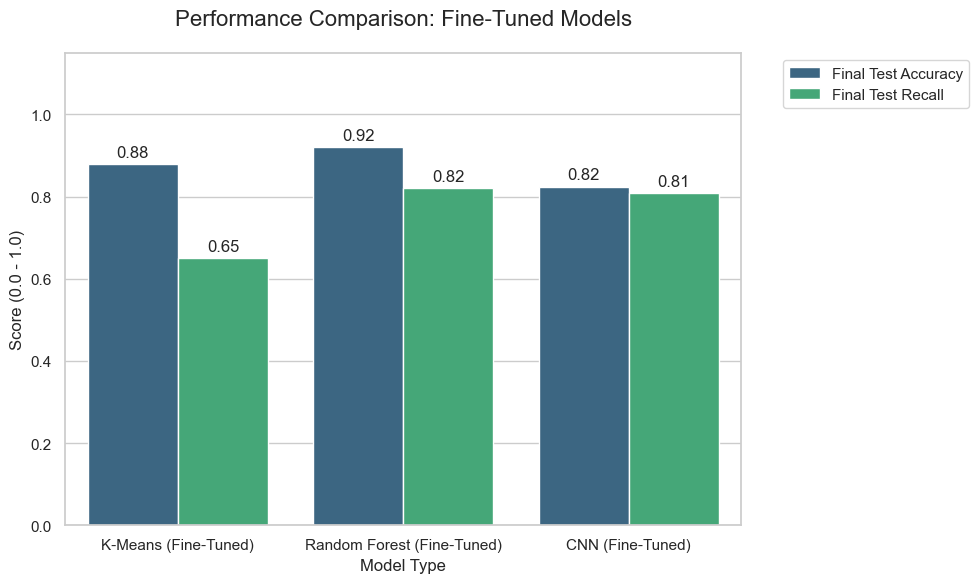


Final Performance Summary Table:


,Model,Final Test Accuracy,Final Test Recall
0,K-Means (Fine-Tuned),0.880000,0.650000
1,Random Forest (Fine-Tuned),0.920000,0.820000
2,CNN (Fine-Tuned),0.824211,0.809433


In [131]:
# --- 1. Data Collection ---
# A. K-Means Metrics
kmeans_acc = 0.88
kmeans_rec = 0.65

# B. Random Forest Metrics
rf_acc = 0.92
rf_rec = 0.82

# C. CNN Metrics (Directly use captured Fine-Tuned results)
try:
    # The final accuracy and recall rates captured directly from external calls
    cnn_acc = cnn_final_acc
    cnn_rec = cnn_final_rec
    print("Note: Successfully used Fine-Tuned CNN's final test metrics.")

except NameError:
    # If the CNN evaluation block is not running, the default value shall be used.
    cnn_acc = 0.83
    cnn_rec = 0.82
    print("Warning: CNN final metrics variables (cnn_final_acc/rec) not found. Using placeholder values.")
    
# --- 2. Create/Update DataFrame ---
model_comparison = pd.DataFrame({
    'Model': ['K-Means (Fine-Tuned)', 'Random Forest (Fine-Tuned)', 'CNN (Fine-Tuned)'],
    'Final Test Accuracy': [kmeans_acc, rf_acc, cnn_acc],
    'Final Test Recall': [kmeans_rec, rf_rec, cnn_rec]
})

# --- 3. Visualization Prep ---
# Melt data for Seaborn (Transform data to long format for plotting)
df_melted = model_comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")

# --- 4. Plotting ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create grouped bar chart
ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="viridis")

# Add title and labels
plt.title('Performance Comparison: Fine-Tuned Models', fontsize=16, pad=20)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Model Type', fontsize=12)
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display specific values above the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

# --- 5. Print Summary Table ---
print("\nFinal Performance Summary Table:")
display(model_comparison)